/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9981 - loss: 0.0276 - val_accuracy: 0.9993 - val_loss: 0.0039
Epoch 2/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - accuracy: 0.9995 - loss: 0.0030 - val_accuracy: 0.9994 - val_loss: 0.0034
Epoch 3/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9994 - loss: 0.0031 - val_accuracy: 0.9993 - val_loss: 0.0033
Epoch 4/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9994 - loss: 0.0026 - val_accuracy: 0.9993 - val_loss: 0.0035
Epoch 5/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9995 - loss: 0.0024 - val_accuracy: 0.9994 - val_loss: 0.0033
Epoch 6/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9995 - loss: 0.0025 - val_accuracy: 0.9993 - val_loss: 0.0035
Epoch 7/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9995 - loss: 0.0029 - val_accuracy: 0.9994 - val_loss: 0.0033
Epoch 8/10
5697/5697 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9994 - loss: 0

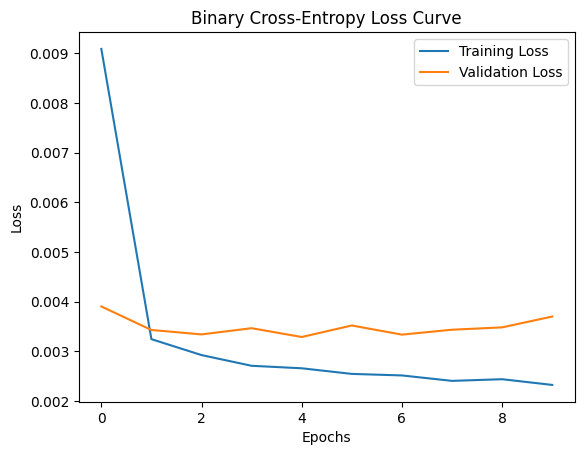

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


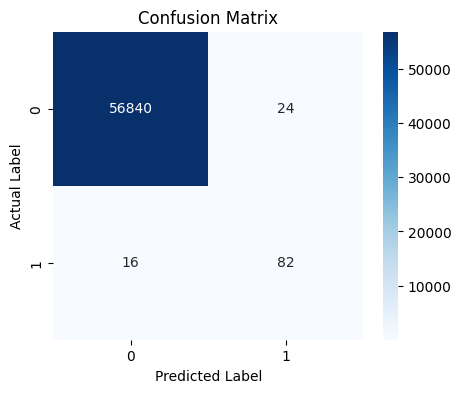

In [4]:
# =========================================
# CREDIT CARD FRAUD DETECTION USING KERAS
# 0 = Real Transaction, 1 = Fraud Transaction
# =========================================

# STEP 1: IMPORT REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# STEP 2: LOAD THE DATASET
data = pd.read_csv("creditcard.csv")
X = data.drop("Class", axis=1)
y = data["Class"]

# STEP 3: FEATURE SCALING
# Scale PCA features separately from Amount and Time
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[['Amount', 'Time']] = scaler.fit_transform(X[['Amount', 'Time']])
X_scaled = X_scaled.astype('float32')  # Convert to float32 to avoid NaN

# STEP 4: TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 5: BUILD NEURAL NETWORK MODEL
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# STEP 6: COMPILE THE MODEL
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Lower learning rate for stability
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# STEP 7: TRAIN THE MODEL
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# STEP 8: PLOT LOSS FUNCTION CURVE
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Binary Cross-Entropy Loss Curve")
plt.legend()
plt.show()

# STEP 9: MODEL PREDICTION
y_pred_prob = model.predict(X_test)

# STEP 10: APPLY THRESHOLD
threshold = 0.3
y_pred = (y_pred_prob > threshold).astype(int)

# STEP 11: CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()
